Raw shape: (64894, 19)
X shape: (64894, 18) | y shape: (64894,)
Train shape: (51915, 18) | Test shape: (12979, 18)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

[RandomizedSearch] Best params: {'knn__weights': 'distance', 'knn__p': 1, 'knn__n_neighbors': 17, 'knn__metric': 'minkowski', 'knn__leaf_size': 20, 'knn__algorithm': 'kd_tree'}
[RandomizedSearch] Best CV score: 0.4895595069205078
[RandomizedSearch] Test R²: 0.4852080013294223
[RandomizedSearch] Test RMSE: 300299.6692320341
[RandomizedSearch] Test MAE: 191943.023960402
Fitting 3 folds for each of 8 candidates, totalling 24 fits

[Cosine Grid] Best params: {'knn__algorithm': 'brute', 'knn__metric': 'cosine', 'knn__n_neighbors': 17, 'knn__weights': 'distance'}
[Cosine Grid] Best CV score: 0.4751648310037227
[Cosine Grid] Test R²: 0.46208039374625265
[Cosine Grid] Test RMSE: 306971.2104484638
[Cosine Grid] Test MAE: 196466.60302818418

Generating validation curve (CV score vs k)...


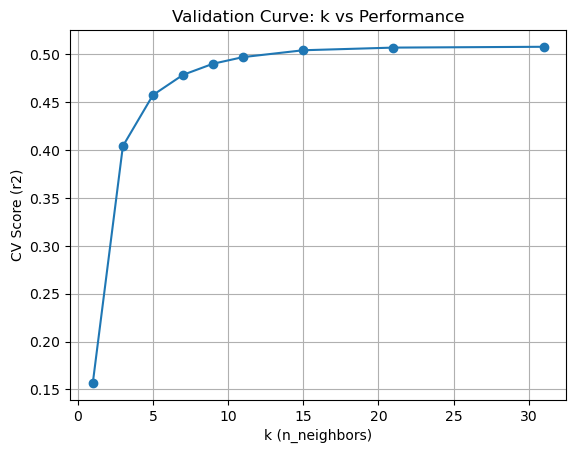


Top CV results from RandomizedSearch:


,param_knn__metric,param_knn__p,param_knn__weights,param_knn__algorithm,param_knn__leaf_size,param_knn__n_neighbors,mean_test_score,std_test_score
15,minkowski,1,distance,kd_tree,20,17,0.489560,0.015832
17,minkowski,1,uniform,auto,30,15,0.484451,0.015700
2,minkowski,1,uniform,kd_tree,20,21,0.483550,0.014182
0,minkowski,1,uniform,ball_tree,40,23,0.483227,0.014402
19,minkowski,1,uniform,kd_tree,40,23,0.483220,0.014403
14,minkowski,2,distance,auto,20,21,0.479202,0.012292
5,minkowski,2,distance,kd_tree,40,19,0.478408,0.011593
1,minkowski,2,distance,auto,30,15,0.476678,0.009460
13,minkowski,2,uniform,ball_tree,20,25,0.470603,0.011195
16,minkowski,2,uniform,ball_tree,30,25,0.470602,0.011204


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, classification_report
)

# --- Config ---
CSV_PATH = "zillow_cleaned.csv"        # <--- change if needed
TASK = "regression"                    # "regression" or "classification"
TARGET = "taxvaluedollarcnt"           # <--- change if doing classification
DROP_COLS = []                         # e.g., ['parcelid']
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Load ---
df = pd.read_csv(CSV_PATH)
print("Raw shape:", df.shape)

# --- Define X, y (numeric-only to keep KNN simple) ---
df_model = df.drop(columns=DROP_COLS, errors='ignore').copy()
df_model = df_model.dropna(subset=[TARGET]).copy()

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Keep numeric predictors only; replace inf w/ NaN (then impute)
X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).copy()

print("X shape:", X.shape, "| y shape:", y.shape)

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

# --- Model choice ---
model = KNeighborsRegressor() if TASK == "regression" else KNeighborsClassifier()

# --- Pipeline: Impute -> Scale -> KNN ---
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("knn", model)
])

# --- Scoring metric (for CV) ---
scoring = "r2" if TASK == "regression" else "f1"

# ============================
# (1) FAST MAIN SEARCH (RandomizedSearchCV) on Minkowski (p in {1,2})
# ============================

# Optional: downsample for CV speed if training set is huge
X_train_fast, y_train_fast = X_train, y_train
MAX_N = 20000
if len(X_train) > MAX_N:
    X_train_fast, _, y_train_fast, _ = train_test_split(
        X_train, y_train, train_size=MAX_N, random_state=RANDOM_STATE
    )

search_space = {
    "knn__n_neighbors": np.arange(3, 26, 2),            # odd k: 3..25
    "knn__metric": ["minkowski"],                        # fast metrics
    "knn__p": [1, 2],                                    # 1=Manhattan, 2=Euclidean
    "knn__weights": ["uniform", "distance"],
    "knn__algorithm": ["auto", "kd_tree", "ball_tree"],  # faster than brute
    "knn__leaf_size": [20, 30, 40]
}

rand = RandomizedSearchCV(
    pipe,
    param_distributions=search_space,
    n_iter=20,
    scoring=scoring,
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
rand.fit(X_train_fast, y_train_fast)

print("\n[RandomizedSearch] Best params:", rand.best_params_)
print("[RandomizedSearch] Best CV score:", rand.best_score_)

best_fast = rand.best_estimator_
y_pred_fast = best_fast.predict(X_test)

if TASK == "regression":
    # Compute RMSE without squared= to support older sklearn versions
    r2_fast  = r2_score(y_test, y_pred_fast)
    rmse_fast = np.sqrt(mean_squared_error(y_test, y_pred_fast))
    mae_fast  = mean_absolute_error(y_test, y_pred_fast)
    print("[RandomizedSearch] Test R²:", r2_fast)
    print("[RandomizedSearch] Test RMSE:", rmse_fast)
    print("[RandomizedSearch] Test MAE:", mae_fast)
else:
    acc_fast = accuracy_score(y_test, y_pred_fast)
    try:
        f1_fast = f1_score(y_test, y_pred_fast)
    except Exception:
        f1_fast = f1_score(y_test, y_pred_fast, average="macro")
    print("[RandomizedSearch] Test Accuracy:", acc_fast)
    print("[RandomizedSearch] Test F1:", f1_fast)
    print("\n[RandomizedSearch] Classification report:\n", classification_report(y_test, y_pred_fast))

# ============================
# (2) OPTIONAL: COSINE small grid (slower; run only if you want to compare)
# ============================

run_cosine = True  # set False to skip
if run_cosine:
    grid_cos_small = GridSearchCV(
        pipe,
        param_grid={
            "knn__n_neighbors": [5, 9, 13, 17],
            "knn__metric": ["cosine"],
            "knn__algorithm": ["brute"],          # cosine requires brute
            "knn__weights": ["uniform", "distance"]
        },
        scoring=scoring,
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    grid_cos_small.fit(X_train_fast, y_train_fast)

    print("\n[Cosine Grid] Best params:", grid_cos_small.best_params_)
    print("[Cosine Grid] Best CV score:", grid_cos_small.best_score_)

    best_cos = grid_cos_small.best_estimator_
    y_pred_cos = best_cos.predict(X_test)

    if TASK == "regression":
        r2_cos   = r2_score(y_test, y_pred_cos)
        rmse_cos = np.sqrt(mean_squared_error(y_test, y_pred_cos))
        mae_cos  = mean_absolute_error(y_test, y_pred_cos)
        print("[Cosine Grid] Test R²:", r2_cos)
        print("[Cosine Grid] Test RMSE:", rmse_cos)
        print("[Cosine Grid] Test MAE:", mae_cos)
    else:
        acc_cos = accuracy_score(y_test, y_pred_cos)
        try:
            f1_cos = f1_score(y_test, y_pred_cos)
        except Exception:
            f1_cos = f1_score(y_test, y_pred_cos, average="macro")
        print("[Cosine Grid] Test Accuracy:", acc_cos)
        print("[Cosine Grid] Test F1:", f1_cos)
        print("\n[Cosine Grid] Classification report:\n", classification_report(y_test, y_pred_cos))

# ============================
# (3) Validation curve: CV score vs k  (uses best metric/weights from fast search)
# ============================

print("\nGenerating validation curve (CV score vs k)...")
best_metric = rand.best_params_.get("knn__metric", "minkowski")
best_p = rand.best_params_.get("knn__p", 2) if best_metric == "minkowski" else None
best_weights = rand.best_params_.get("knn__weights", "uniform")
best_algo = rand.best_params_.get("knn__algorithm", "auto")

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
cv_scores = []

for k in k_values:
    if TASK == "regression":
        mdl = KNeighborsRegressor(
            n_neighbors=k,
            metric=best_metric,
            **({"p": best_p} if (best_metric == "minkowski") else {}),
            algorithm=best_algo,
            weights=best_weights
        )
    else:
        mdl = KNeighborsClassifier(
            n_neighbors=k,
            metric=best_metric,
            **({"p": best_p} if (best_metric == "minkowski") else {}),
            algorithm=best_algo,
            weights=best_weights
        )
    pipe_k = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("knn", mdl)
    ])
    scores = cross_val_score(pipe_k, X_train, y_train, cv=3, scoring=scoring, n_jobs=-1)
    cv_scores.append(scores.mean())

plt.figure()
plt.plot(k_values, cv_scores, marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel(f"CV Score ({scoring})")
plt.title("Validation Curve: k vs Performance")
plt.grid(True)
plt.show()

# ============================
# (4) CV results summary table (from fast search)
# ============================

print("\nTop CV results from RandomizedSearch:")
res = pd.DataFrame(rand.cv_results_)
cols = [
    "param_knn__metric", "param_knn__p", "param_knn__weights",
    "param_knn__algorithm", "param_knn__leaf_size", "param_knn__n_neighbors",
    "mean_test_score", "std_test_score"
]
summary = res[[c for c in cols if c in res.columns]].sort_values("mean_test_score", ascending=False)
display(summary.head(12))